# Reactive vs. Proactive Care: Analysis on Healthcare Inequities and Predicting Diabetes Readmissions


## Overview
This notebook examines whether healthcare utilization patterns and race are related to
hospital readmission among patients with diabetes, and how well machine learning models
can predict readmission.

**Data:** Diabetes 130-US Hospitals (1999-2008), UCI Machine Learning Repository
(101,766 inpatient encounters, 50 columns).

**Outcome:** Readmission is coded as 1 if the patient was readmitted at any time
(`<30` or `>30` days) and 0 as otherwise (`NO`). There about 46% of encounters that are positive.

**Contents:** EDA → K-Means clustering → SMOTE vs. class weighting (Logistic Regression,
Random Forest, XGBoost) → hyperparameter tuning.

### Loading The Data

In [ ]:
import warnings
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np 
import time 

from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    GridSearchCV, RandomizedSearchCV)

from sklearn.cluster import KMeans
from scipy.stats import chi2_contingency

from sklearn.metrics import (classification_report,
                              confusion_matrix, roc_auc_score, f1_score, adjusted_mutual_info_score, 
                              mutual_info_score, normalized_mutual_info_score, mean_squared_error)

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegressionCV, LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [2]:
warnings.filterwarnings("ignore")

In [3]:
dataset = fetch_ucirepo(id=296)
df = dataset.data.original.copy()
print(df.head())

   encounter_id  patient_nbr             race  gender      age weight  \
0       2278392      8222157        Caucasian  Female   [0-10)    NaN   
1        149190     55629189        Caucasian  Female  [10-20)    NaN   
2         64410     86047875  AfricanAmerican  Female  [20-30)    NaN   
3        500364     82442376        Caucasian    Male  [30-40)    NaN   
4         16680     42519267        Caucasian    Male  [40-50)    NaN   

   admission_type_id  discharge_disposition_id  admission_source_id  \
0                  6                        25                    1   
1                  1                         1                    7   
2                  1                         1                    7   
3                  1                         1                    7   
4                  1                         1                    7   

   time_in_hospital  ... citoglipton insulin  glyburide-metformin  \
0                 1  ...          No      No                   No

### Exploratory Data Analysis (EDA)

In [4]:
df.replace("?", np.nan, inplace=True)


In [5]:
df.isnull().sum()

encounter_id                    0
patient_nbr                     0
race                         2273
gender                          0
age                             0
weight                      98569
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                  40256
medical_specialty           49949
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                         21
diag_2                        358
diag_3                       1423
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [6]:
medications = df[["metformin", "metformin-pioglitazone", "repaglinide", "nateglinide", "chlorpropamide", "glimepiride", 
                  "acetohexamide", "glipizide", "glyburide", "tolbutamide", "pioglitazone", "rosiglitazone", "acarbose",
                  "miglitol", "troglitazone", "tolazamide", "examide", "citoglipton", "insulin", "glyburide-metformin",
                  "glipizide-metformin", "glimepiride-pioglitazone", "metformin-rosiglitazone"]]

meds_up = (medications == "Up")
meds_down = (medications == "Down")
meds_steady = (medications == "Steady")

df["med_change_count"] = (meds_up | meds_down).sum(axis=1)
df["med_steady_count"] = (meds_steady).sum(axis=1)

meds_cols= ['metformin', 'med_change_count', 'med_steady_count']
df[meds_cols].head(20)

,metformin,med_change_count,med_steady_count
0,No,0,0
1,No,1,0
2,No,0,1
3,No,1,0
4,No,0,2
5,No,0,1
6,Steady,0,3
7,No,0,1
8,No,0,2
9,No,0,2


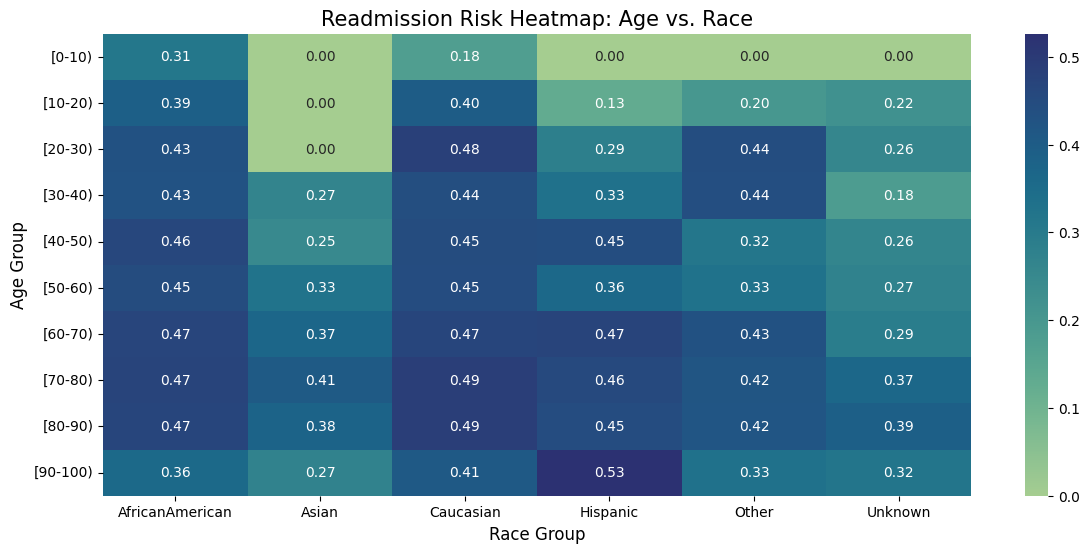

In [7]:
mapping = {"NO": 0, ">30": 1, "<30":1}
df["readmitted_num"] = df["readmitted"].map(mapping)

df['race_fill'] = df['race'].fillna("Unknown")

race_heatmap = df.groupby(["age", "race_fill"])["readmitted_num"].mean().unstack()
plt.figure(figsize=(14,6))
sns.heatmap(race_heatmap, annot=True, cmap="crest", fmt=".2f")

plt.title("Readmission Risk Heatmap: Age vs. Race", fontsize=15)
plt.xlabel("Race Group", fontsize=12)
plt.ylabel("Age Group", fontsize=12)
plt.savefig("readmission_heatmap_age_race.png")
plt.show()

In [8]:
by_race = df.groupby("race_fill")["readmitted_num"].agg(n="size", readmitted="sum", rate="mean")
by_race["rate"] = (by_race["rate"] * 100).round(2)
print(by_race)

                     n  readmitted   rate
race_fill                                
AfricanAmerican  19210        8789  45.75
Asian              641         226  35.26
Caucasian        76099       35716  46.93
Hispanic          2037         854  41.92
Other             1506         591  39.24
Unknown           2273         726  31.94


In [9]:
table = pd.crosstab(df["race_fill"], df["readmitted_num"])

chi2, p, dof, expected = chi2_contingency(table)

print(f"Chi-Square Statistics: {chi2:.4f}\n")
print(f"P-Value: {p:.4f}")

if p < 0.05: 
    print("Statistically significant.")
else: 
    print("Not statistically significant.")

Chi-Square Statistics: 278.7505

P-Value: 0.0000
Statistically significant.


In [10]:
v = np.sqrt(chi2 / (table.values.sum() * (min(table.shape) - 1)))
print(f"Cramér's V: {v:.3f}")

Cramér's V: 0.052


<Figure size 1200x600 with 0 Axes>

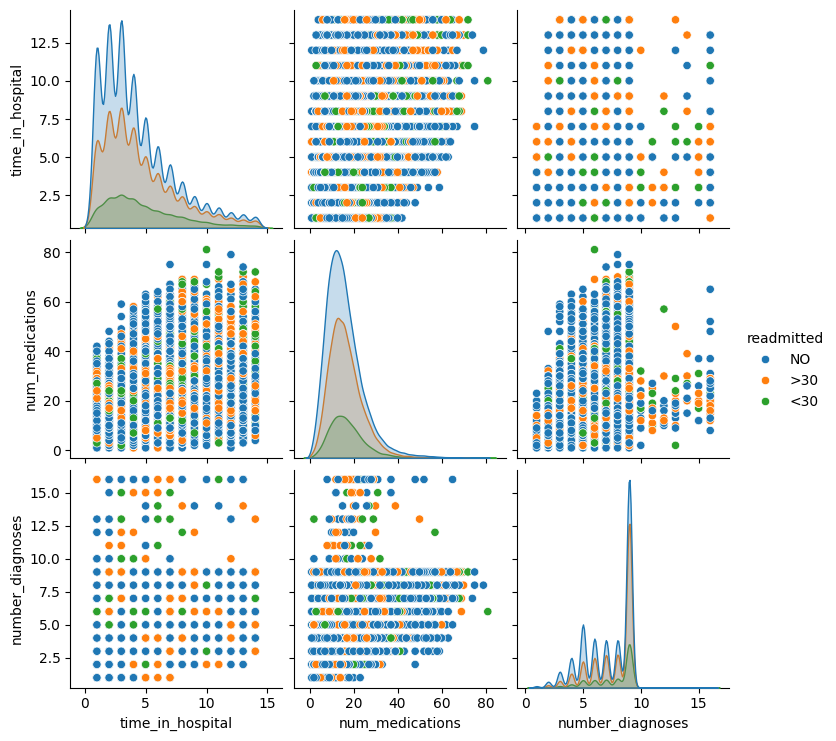

In [11]:
plt.figure(figsize=(12,6))
sns.pairplot(df, vars=['time_in_hospital', 'num_medications', 'number_diagnoses'], hue='readmitted')
plt.savefig("pair_plot.png")
plt.show()

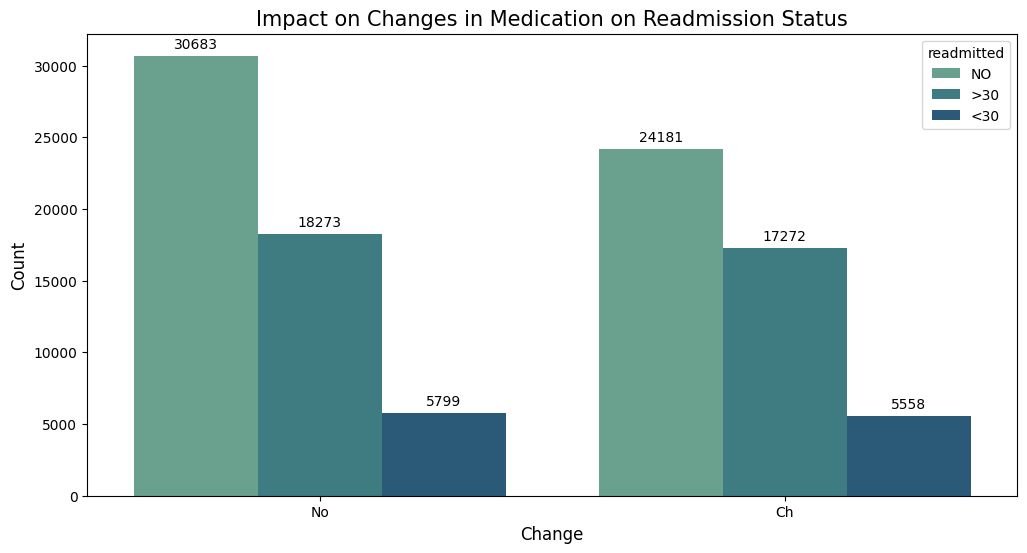

In [12]:
plt.figure(figsize=(12,6))
ax = sns.countplot(data=df, x="change", hue="readmitted",  palette="crest")
plt.title("Impact on Changes in Medication on Readmission Status", fontsize=15)
plt.xlabel("Change", fontsize=12)
plt.ylabel("Count", fontsize=12)

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.savefig("medication_changes_count.png")
plt.show()

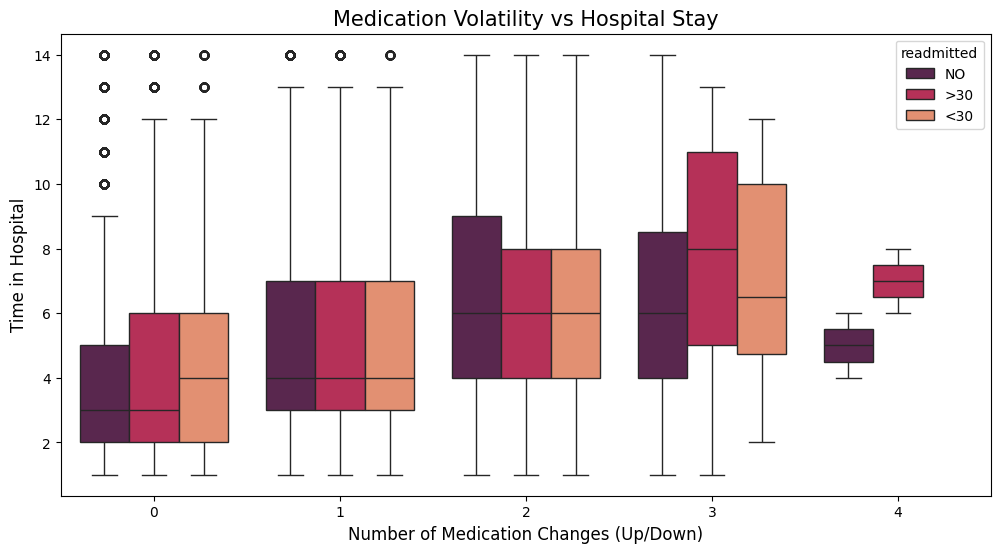

In [13]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="med_change_count", y="time_in_hospital", 
              hue="readmitted", palette="rocket")

plt.title("Medication Volatility vs Hospital Stay", fontsize=15)
plt.xlabel("Number of Medication Changes (Up/Down)", fontsize=12)
plt.ylabel("Time in Hospital", fontsize=12)

plt.savefig("volatility_vs_hospital_stay.png")
plt.show()

In [14]:
df.groupby(["med_change_count", "readmitted_num"])["time_in_hospital"].describe()[["25%", "50%", "75%"]]

25%  50%   75%
med_change_count readmitted_num                
0                0               2.0  3.0   5.0
                 1               2.0  4.0   6.0
1                0               3.0  4.0   7.0
                 1               3.0  4.0   7.0
2                0               4.0  6.0   9.0
                 1               4.0  6.0   8.0
3                0               4.0  6.0   8.5
                 1               5.0  7.0  10.0
4                0               4.5  5.0   5.5
                 1               6.5  7.0   7.5

### K-Means Clustering

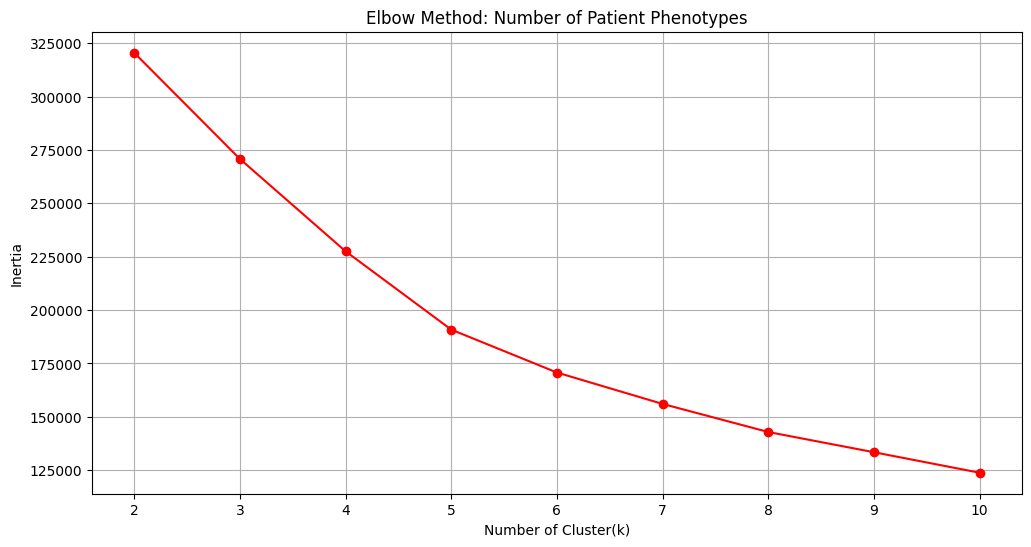

                  time_in_hospital  num_medications  med_change_count  \
Patient_Clusters                                                        
0                             4.57            16.78              0.36   
1                             4.01            16.19              1.07   
2                             9.00            26.00              0.29   
3                             3.12            12.76              0.00   
4                             4.18            17.44              0.33   

                  number_outpatient  number_inpatient  
Patient_Clusters                                       
0                              0.50              4.38  
1                              0.23              0.41  
2                              0.21              0.51  
3                              0.20              0.32  
4                              6.23              0.91  


In [15]:
X = df.drop(["readmitted", "readmitted_num"], axis=1)
y = df["readmitted_num"] 

X_train, X_test, y_train, y_test = train_test_split(    
    X, y, test_size=0.2, stratify=y, random_state=42)

cluster_features = ["time_in_hospital", "num_medications", "med_change_count", "number_outpatient", "number_inpatient"]

scaler_km = StandardScaler()
X_train_scaled = scaler_km.fit_transform(X_train[cluster_features].fillna(0))
X_test_scaled = scaler_km.transform(X_test[cluster_features].fillna(0))

inertia = [] 

for k in range(2, 11): 
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) 
    kmeans.fit(X_train_scaled) 
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(12,6))
plt.plot(range(2,11), inertia, marker="o", linestyle="-", color="r")
plt.title("Elbow Method: Number of Patient Phenotypes")
plt.xlabel("Number of Cluster(k)")
plt.ylabel("Inertia")
plt.xticks(range(2, 11))
plt.grid(True)
plt.show()


kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
X_train["Patient_Clusters"] = kmeans.fit_predict(X_train_scaled)
X_test["Patient_Clusters"] = kmeans.predict(X_test_scaled)

centroids = X_train.groupby("Patient_Clusters")[cluster_features].mean()
print(centroids.round(2))

In [16]:
cluster_race = pd.crosstab(X_train["race_fill"],X_train["Patient_Clusters"], normalize="index").round(4)*100
print(cluster_race)

Patient_Clusters     0      1      2      3     4
race_fill                                        
AfricanAmerican   7.30  20.09  16.91  54.45  1.25
Asian             4.97  19.69  11.85  62.91  0.57
Caucasian         6.03  19.11  16.95  55.14  2.77
Hispanic          6.56  21.86  11.46  58.08  2.04
Other             4.42  27.96  14.61  51.84  1.17
Unknown           2.05  18.74  16.47  61.42  1.33


In [17]:
cluster_gender = pd.crosstab(X_train["gender"],X_train["Patient_Clusters"], normalize="index").round(4)*100
print(cluster_gender)

Patient_Clusters     0      1      2      3     4
gender                                           
Female            6.32  19.29  17.14  54.73  2.52
Male              5.98  19.70  16.31  55.76  2.25
Unknown/Invalid   0.00   0.00  33.33  66.67  0.00


In [18]:
readmit_train = df.loc[X_train.index, "readmitted"] 

mi_readmit  = mutual_info_score(readmit_train, X_train["Patient_Clusters"])
ami_readmit = adjusted_mutual_info_score(readmit_train, X_train["Patient_Clusters"])
nmi_readmit = normalized_mutual_info_score(readmit_train, X_train["Patient_Clusters"])

ami_age  = adjusted_mutual_info_score(X_train["age"], readmit_train)
ami_race = adjusted_mutual_info_score(X_train["race_fill"], readmit_train)

print(f"Clusters vs Readmission (MI):  {mi_readmit:.4f}")
print(f"Clusters vs Readmission (AMI): {ami_readmit:.4f}")
print(f"Clusters vs Readmission (NMI): {nmi_readmit:.4f}\n")
print(f"Age vs Readmission (AMI):      {ami_age:.4f}")
print(f"Race vs Readmission (AMI):      {ami_race:.4f}")

Clusters vs Readmission (MI):  0.0167
Clusters vs Readmission (AMI): 0.0154
Clusters vs Readmission (NMI): 0.0155

Age vs Readmission (AMI):      0.0011
Race vs Readmission (AMI):      0.0017


### SKFold Test

In [19]:
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

for fold, (train_index, test_index) in enumerate(skf.split(X_train_scaled, y_train)):

    y_train_fold = y_train.iloc[train_index]
    y_test_fold = y_train.iloc[test_index]
    
    train_readmitted = y_train_fold.mean() * 100
    test_readmitted = y_test_fold.mean() * 100

    print(f"\nFold {fold + 1}:")
    print(f"Train: {len(train_index)} samples ({train_readmitted:.1f}% readmitted)")
    print(f"Test: {len(test_index)} samples ({test_readmitted:.1f}% readmitted)")


Fold 1:
Train: 73270 samples (46.1% readmitted)
Test: 8142 samples (46.1% readmitted)

Fold 2:
Train: 73270 samples (46.1% readmitted)
Test: 8142 samples (46.1% readmitted)

Fold 3:
Train: 73271 samples (46.1% readmitted)
Test: 8141 samples (46.1% readmitted)

Fold 4:
Train: 73271 samples (46.1% readmitted)
Test: 8141 samples (46.1% readmitted)

Fold 5:
Train: 73271 samples (46.1% readmitted)
Test: 8141 samples (46.1% readmitted)

Fold 6:
Train: 73271 samples (46.1% readmitted)
Test: 8141 samples (46.1% readmitted)

Fold 7:
Train: 73271 samples (46.1% readmitted)
Test: 8141 samples (46.1% readmitted)

Fold 8:
Train: 73271 samples (46.1% readmitted)
Test: 8141 samples (46.1% readmitted)

Fold 9:
Train: 73271 samples (46.1% readmitted)
Test: 8141 samples (46.1% readmitted)

Fold 10:
Train: 73271 samples (46.1% readmitted)
Test: 8141 samples (46.1% readmitted)


### Machine Learning Algorithms

In [20]:
num_features = [
    "time_in_hospital", "number_inpatient", "number_outpatient", 
    "number_emergency", "num_medications","admission_source_id", "med_change_count"
    ]

cat_features = [
    "age", "gender", "race", "metformin","change", "A1Cresult"
    ]

cat_features_pc = [
    "age", "gender", "race", "metformin","change", "A1Cresult", "Patient_Clusters"
    ]

#### With SMOTE

In [21]:
cat_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(sparse_output=False, handle_unknown="ignore")),
])

num_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

prep = ColumnTransformer(transformers=[
    ("num", num_pipeline, num_features),
    ("cat", cat_pipeline, cat_features)
])

models = { 
    "Logistic Regression": LogisticRegressionCV(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42)
        }


smote = SMOTE(random_state=42)

smote_results = []
    
for name, model in models.items():
    pipeline = ImbPipeline(steps=[
        ("preprocessor", prep),
        ("smote", SMOTE(random_state=42)), 
        ("classifier", model)
     ]) 

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    y_prob = pipeline.predict_proba(X_test)[:, 1]
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    report = classification_report(y_test, y_pred, output_dict=True)
    smote_results.append({
         "Model": name, 
         "Accuracy": report["accuracy"],
         "Recall (Class 0)": report["0"]["recall"],
         "Recall (class 1)": report["1"]["recall"],
         "AUC": roc_auc_score(y_test, y_prob),
        "F1": f1_score(y_test, y_pred),
         "True Positives": tp, 
        "True Negatives": tn, 
         "False Positives": fp, 
        "False Negatives": fn

     })

results_df = pd.DataFrame(smote_results)
summary = results_df.groupby("Model")[["Accuracy", "Recall (Class 0)", "Recall (class 1)", "AUC",
                                        "F1", "True Positives", "True Negatives", "False Positives", 
                                        "False Negatives"]].mean().round(3)
print(summary)

                     Accuracy  Recall (Class 0)  Recall (class 1)    AUC  \
Model                                                                      
Logistic Regression     0.617             0.732             0.482  0.650   
Random Forest           0.572             0.599             0.541  0.598   
XGBoost                 0.622             0.721             0.506  0.661   

                        F1  True Positives  True Negatives  False Positives  \
Model                                                                         
Logistic Regression  0.537          4523.0          8029.0           2944.0   
Random Forest        0.538          5072.0          6571.0           4402.0   
XGBoost              0.553          4750.0          7912.0           3061.0   

                     False Negatives  
Model                                 
Logistic Regression           4858.0  
Random Forest                 4309.0  
XGBoost                       4631.0  


#### SMOTE with Patient Clusters

In [22]:
cat_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(sparse_output=False, handle_unknown="ignore")),
])

num_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

prep_pc = ColumnTransformer(transformers=[
    ("num", num_pipeline, num_features),
    ("cat", cat_pipeline, cat_features_pc)
])

models = { 
    "Logistic Regression": LogisticRegressionCV(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42)
        }

smote = SMOTE(random_state=42)

smote_patient_results = []

for name, model in models.items():
    pipeline = ImbPipeline(steps=[
        ("preprocessor", prep_pc),
        ("smote", SMOTE(random_state=42)), 
        ("classifier", model)
     ]) 

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    y_prob = pipeline.predict_proba(X_test)[:, 1]
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    report = classification_report(y_test, y_pred, output_dict=True)
    smote_patient_results.append({
         "Model": name, 
         "Accuracy": report["accuracy"],
         "Recall (Class 0)": report["0"]["recall"],
         "Recall (class 1)": report["1"]["recall"],
         "AUC": roc_auc_score(y_test, y_prob),
        "F1": f1_score(y_test, y_pred),
         "True Positives": tp, 
        "True Negatives": tn, 
         "False Positives": fp, 
        "False Negatives": fn

     })

results_df = pd.DataFrame(smote_patient_results)
summary = results_df.groupby("Model")[["Accuracy", "Recall (Class 0)", "Recall (class 1)", "AUC",
                                        "F1", "True Positives", "True Negatives", "False Positives", 
                                        "False Negatives"]].mean().round(3)
print(summary)

                     Accuracy  Recall (Class 0)  Recall (class 1)    AUC  \
Model                                                                      
Logistic Regression     0.621             0.729             0.495  0.652   
Random Forest           0.575             0.606             0.538  0.597   
XGBoost                 0.622             0.720             0.508  0.660   

                        F1  True Positives  True Negatives  False Positives  \
Model                                                                         
Logistic Regression  0.546          4640.0          7996.0           2977.0   
Random Forest        0.538          5047.0          6655.0           4318.0   
XGBoost              0.553          4762.0          7906.0           3067.0   

                     False Negatives  
Model                                 
Logistic Regression           4741.0  
Random Forest                 4334.0  
XGBoost                       4619.0  


#### Class Weights

In [32]:
cat_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(sparse_output=False, handle_unknown="ignore")),
])

num_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

prep = ColumnTransformer(transformers=[
    ("num", num_pipeline, num_features),
    ("cat", cat_pipeline, cat_features)
])

models = {
    "Logistic Regression": LogisticRegressionCV(
        class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(
        class_weight="balanced", random_state=42),
    "XGBoost": XGBClassifier(
        scale_pos_weight=1.17, random_state=42)
}
cw_results = []

for name, model in models.items():
    pipeline = ImbPipeline(steps=[
       ("preprocessor", prep),
       ("classifier", model)
    ]) 

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    y_prob = pipeline.predict_proba(X_test)[:, 1]
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()


    report = classification_report(y_test, y_pred, output_dict=True)
    cw_results.append({
         "Model": name, 
         "Accuracy": report["accuracy"],
         "Recall (Class 0)": report["0"]["recall"],
         "Recall (class 1)": report["1"]["recall"],
         "AUC": roc_auc_score(y_test, y_prob),
        "F1": f1_score(y_test, y_pred),
         "True Positives": tp, 
        "True Negatives": tn, 
         "False Positives": fp, 
        "False Negatives": fn

     })

results_df = pd.DataFrame(cw_results)
summary = results_df.groupby("Model")[[
    "Accuracy", "Recall (Class 0)", "Recall (class 1)", "AUC", 
    "F1", "True Positives", "True Negatives", "False Positives", 
    "False Negatives"]].mean().round(3)

print(summary)

                     Accuracy  Recall (Class 0)  Recall (class 1)    AUC  \
Model                                                                      
Logistic Regression     0.618             0.737             0.480  0.651   
Random Forest           0.575             0.606             0.538  0.597   
XGBoost                 0.620             0.662             0.570  0.662   

                        F1  True Positives  True Negatives  False Positives  \
Model                                                                         
Logistic Regression  0.537          4500.0          8084.0           2889.0   
Random Forest        0.538          5048.0          6648.0           4325.0   
XGBoost              0.580          5346.0          7268.0           3705.0   

                     False Negatives  
Model                                 
Logistic Regression           4881.0  
Random Forest                 4333.0  
XGBoost                       4035.0  


#### Class Weights with Patient Clusters

In [33]:
cat_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(sparse_output=False, handle_unknown="ignore")),
])

num_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

prep_pc = ColumnTransformer(transformers=[
    ("num", num_pipeline, num_features),
    ("cat", cat_pipeline, cat_features_pc)
])

models = {
    "Logistic Regression": LogisticRegressionCV(
        class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(
        class_weight="balanced", random_state=42),
    "XGBoost": XGBClassifier(
        scale_pos_weight=1.17, random_state=42)
}

cw_patient_results = []

for name, model in models.items():
    pipeline = ImbPipeline(steps=[
       ("preprocessor", prep_pc),
       ("classifier", model)
    ]) 

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    y_prob = pipeline.predict_proba(X_test)[:, 1]
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()


    report = classification_report(y_test, y_pred, output_dict=True)
    cw_patient_results.append({
         "Model": name, 
         "Accuracy": report["accuracy"],
         "Recall (Class 0)": report["0"]["recall"],
         "Recall (class 1)": report["1"]["recall"],
         "AUC": roc_auc_score(y_test, y_prob),
        "F1": f1_score(y_test, y_pred),
         "True Positives": tp, 
        "True Negatives": tn, 
         "False Positives": fp, 
        "False Negatives": fn

     })

results_df = pd.DataFrame(cw_patient_results)
summary = results_df.groupby("Model")[[
    "Accuracy", "Recall (Class 0)", "Recall (class 1)", "AUC", 
    "F1", "True Positives", "True Negatives", "False Positives", 
    "False Negatives"]].mean().round(3)

print(summary)

                     Accuracy  Recall (Class 0)  Recall (class 1)    AUC  \
Model                                                                      
Logistic Regression     0.621             0.734             0.489  0.652   
Random Forest           0.573             0.608             0.532  0.598   
XGBoost                 0.620             0.663             0.571  0.662   

                        F1  True Positives  True Negatives  False Positives  \
Model                                                                         
Logistic Regression  0.543          4590.0          8049.0           2924.0   
Random Forest        0.534          4987.0          6672.0           4301.0   
XGBoost              0.581          5352.0          7271.0           3702.0   

                     False Negatives  
Model                                 
Logistic Regression           4791.0  
Random Forest                 4394.0  
XGBoost                       4029.0  


### Hyperparameter Tuning

In [25]:
lr_tuning_pipeline = ImbPipeline(steps=[
    ("preprocessor", prep_pc),
    ("smote", SMOTE(random_state=42)), 
    ("classifier", LogisticRegression(random_state=42, max_iter=1000)) 
])

param_grid_lr = {
    "classifier__penalty": ["l1", "l2"],
    "classifier__solver": ["liblinear", "saga"], 
    "classifier__C": [0.1, 1, 10, 100]
}

grid_search_lr = GridSearchCV(
    lr_tuning_pipeline, 
    param_grid_lr, 
    cv=skf, 
    scoring="f1", 
    n_jobs=-1)

grid_search_lr.fit(X_train, y_train)

print("Best Parameters for LR (SMOTE):")
print(grid_search_lr.best_params_)

y_pred_lr = grid_search_lr.predict(X_test)

y_prob_lr = grid_search_lr.predict_proba(X_test)[:, 1]

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))
print(f"\nAUC Score: {roc_auc_score(y_test, y_prob_lr):.3f}")

Best Parameters for LR (SMOTE):
{'classifier__C': 100, 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}

Confusion Matrix:
[[7995 2978]
 [4742 4639]]

Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.73      0.67     10973
           1       0.61      0.49      0.55      9381

    accuracy                           0.62     20354
   macro avg       0.62      0.61      0.61     20354
weighted avg       0.62      0.62      0.62     20354


AUC Score: 0.652


In [26]:
lr_tuning_pipeline2 = ImbPipeline(steps=[
    ("preprocessor", prep_pc),
    ("classifier", LogisticRegression(random_state=42, class_weight="balanced", max_iter=1000))
])

grid_search_lr2 = GridSearchCV(
    lr_tuning_pipeline2, 
    param_grid_lr, 
    cv=skf, 
    scoring="f1", 
    n_jobs=-1)

grid_search_lr2.fit(X_train, y_train) 

print("Best Parameters for LR (Class Weights):")
print(grid_search_lr2.best_params_)

y_pred_lr2 = grid_search_lr2.predict(X_test)
 
y_prob_lr2 = grid_search_lr2.predict_proba(X_test)[:, 1]

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr2))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr2))
print(f"\nAUC Score: {roc_auc_score(y_test, y_prob_lr2):.3f}")

Best Parameters for LR (Class Weights):
{'classifier__C': 100, 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}

Confusion Matrix:
[[8005 2968]
 [4744 4637]]

Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.73      0.67     10973
           1       0.61      0.49      0.55      9381

    accuracy                           0.62     20354
   macro avg       0.62      0.61      0.61     20354
weighted avg       0.62      0.62      0.62     20354


AUC Score: 0.652


In [27]:
rf_tuning_pipeline = ImbPipeline(steps=[
    ("preprocessor", prep_pc),
    ("smote", SMOTE(random_state=42)), 
    ("classifier", RandomForestClassifier(random_state=42))
])

param_grid_rf = {
"classifier__n_estimators": [100, 200, 300, 500],
    "classifier__max_depth": [3, 5, None],
    "classifier__min_samples_split": [2, 5],
    "classifier__max_features": ["sqrt", "log2", None]
}

grid_search_rf = GridSearchCV(
    rf_tuning_pipeline, 
    param_grid_rf, 
    cv=skf, 
    scoring="f1", 
    n_jobs=-1
    )

start_time = time.time()

grid_search_rf.fit(X_train, y_train)

end_time = time.time()
elapsed_time = (end_time - start_time) / 60

print(f"Model Running Time: {elapsed_time:.2f} minutes")

print("Best Parameters for RF (SMOTE with Grid Search):")
print(grid_search_rf.best_params_)

y_pred_rf = grid_search_rf.predict(X_test)

y_prob_rf = grid_search_rf.predict_proba(X_test)[:, 1]

end_time = time.time()
elapsed_time = (end_time - start_time) / 60

print(f"Model Running Time: {elapsed_time:.2f} minutes")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print("\n Grid Search Classification Report:")
print(classification_report(y_test, y_pred_rf))
print(f"\nAUC Score: {roc_auc_score(y_test, y_prob_rf):.3f}")

Model Running Time: 26.11 minutes
Best Parameters for RF (SMOTE with Grid Search):
{'classifier__max_depth': 5, 'classifier__max_features': 'log2', 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}
Model Running Time: 26.11 minutes

Confusion Matrix:
[[7919 3054]
 [4654 4727]]

 Grid Search Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.72      0.67     10973
           1       0.61      0.50      0.55      9381

    accuracy                           0.62     20354
   macro avg       0.62      0.61      0.61     20354
weighted avg       0.62      0.62      0.62     20354


AUC Score: 0.656


In [28]:
rf_tuning_pipeline = ImbPipeline(steps=[
    ("preprocessor", prep_pc),
    ("smote", SMOTE(random_state=42)), 
    ("classifier", RandomForestClassifier(random_state=42))
])

param_grid_rf = {
"classifier__n_estimators": [100, 200, 300, 500],
    "classifier__max_depth": [3, 5, None],
    "classifier__min_samples_split": [2, 5],
    "classifier__max_features": ["sqrt", "log2", None]
}

random_search_rf = RandomizedSearchCV(
    estimator=rf_tuning_pipeline, 
    param_distributions=param_grid_rf, 
    n_iter=15,
    cv=skf, 
    scoring="f1", 
    n_jobs=-1,
    random_state=42
    )

start_time = time.time()

random_search_rf.fit(X_train, y_train)

print("Best Parameters for RF (SMOTE with Random Search):")
print(random_search_rf.best_params_)

y_pred_rf_rand = random_search_rf.predict(X_test)

y_prob_rf_rand = random_search_rf.predict_proba(X_test)[:, 1]

end_time = time.time()
elapsed_time = (end_time - start_time) / 60

print(f"Model Running Time: {elapsed_time:.2f} minutes")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf_rand))
print("\n Grid Search Classification Report:")
print(classification_report(y_test, y_pred_rf_rand))
print(f"\nAUC Score: {roc_auc_score(y_test, y_prob_rf_rand):.3f}")

Best Parameters for RF (SMOTE with Random Search):
{'classifier__n_estimators': 500, 'classifier__min_samples_split': 5, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 5}
Model Running Time: 3.89 minutes

Confusion Matrix:
[[7758 3215]
 [4534 4847]]

 Grid Search Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.71      0.67     10973
           1       0.60      0.52      0.56      9381

    accuracy                           0.62     20354
   macro avg       0.62      0.61      0.61     20354
weighted avg       0.62      0.62      0.62     20354


AUC Score: 0.656


In [29]:
rf_tuning_pipeline2 = ImbPipeline(steps=[
    ("preprocessor", prep_pc),
    ("classifier", RandomForestClassifier(random_state=42))
])

param_grid_rf2 = {
    "classifier__n_estimators": [100, 200, 300, 500],
    "classifier__max_depth": [3, 5, None],
    "classifier__min_samples_split": [2, 5],
    "classifier__max_features": ["sqrt", "log2", None],
    "classifier__class_weight": ["balanced", None] 
}

random_search_rf2 = RandomizedSearchCV(
    estimator=rf_tuning_pipeline2, 
    param_distributions=param_grid_rf2, 
    n_iter=15,
    cv=skf, 
    scoring="f1", 
    n_jobs=-1,
    random_state=42
)

random_search_rf2.fit(X_train, y_train)

print("Best Parameters for RF (Class Weight with Random Search):")

print(random_search_rf2.best_params_)

y_pred_rf_rand2 = random_search_rf2.predict(X_test)
y_prob_rf_rand2 = random_search_rf2.predict_proba(X_test)[:, 1]

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf_rand2))
print("\n Class Weight Random Search Classification Report:")
print(classification_report(y_test, y_pred_rf_rand2))
print(f"\nAUC Score: {roc_auc_score(y_test, y_prob_rf_rand2):.3f}")

Best Parameters for RF (Class Weight with Random Search):
{'classifier__n_estimators': 500, 'classifier__min_samples_split': 2, 'classifier__max_features': None, 'classifier__max_depth': 3, 'classifier__class_weight': 'balanced'}

Confusion Matrix:
[[7312 3661]
 [4159 5222]]

 Class Weight Random Search Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.67      0.65     10973
           1       0.59      0.56      0.57      9381

    accuracy                           0.62     20354
   macro avg       0.61      0.61      0.61     20354
weighted avg       0.61      0.62      0.61     20354


AUC Score: 0.648


In [30]:
xg_tuning_pipeline = ImbPipeline(steps=[
    ("preprocessor", prep_pc),
    ("smote", SMOTE(random_state=42)), 
    ("classifier", XGBClassifier(random_state=42, eval_metric="logloss"))
])

param_grid_xg = {
    "classifier__n_estimators": [100, 200, 300, 500],
    "classifier__max_depth": [3, 5, 7, None],        
    "classifier__learning_rate": [0.01, 0.1],  
}

random_search_xg = RandomizedSearchCV(
    estimator=xg_tuning_pipeline, 
    param_distributions=param_grid_xg, 
    n_iter=15,
    cv=skf, 
    scoring="f1", 
    n_jobs=-1,
    random_state=42
    )

random_search_xg.fit(X_train, y_train)

print("Best Parameters for XGBoost (SMOTE):")
print(random_search_xg.best_params_)

y_pred_xg = random_search_xg.predict(X_test)

y_prob_xg = random_search_xg.predict_proba(X_test)[:, 1]

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xg))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xg))
print("\nMean Squared Error:")
print(f"{mean_squared_error(y_test, y_pred_xg)*100:.2f}%")
print("\n AUC:")
print(f"{roc_auc_score(y_test, y_prob_xg):.3f}")

Best Parameters for XGBoost (SMOTE):
{'classifier__n_estimators': 500, 'classifier__max_depth': 7, 'classifier__learning_rate': 0.01}

Confusion Matrix:
[[7863 3110]
 [4503 4878]]

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.72      0.67     10973
           1       0.61      0.52      0.56      9381

    accuracy                           0.63     20354
   macro avg       0.62      0.62      0.62     20354
weighted avg       0.62      0.63      0.62     20354


Mean Squared Error:
37.40%

 AUC:
0.665


In [31]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

weight_ratio = neg / pos

xg_tuning_pipeline2 = ImbPipeline(steps=[
    ("preprocessor", prep_pc),
    ("classifier", XGBClassifier(random_state=42, eval_metric="logloss",scale_pos_weight=weight_ratio))
])

param_grid_xg2 = {
    "classifier__n_estimators": [100, 200, 300, 500],
    "classifier__max_depth": [3, 5, 7, None],        
    "classifier__learning_rate": [0.01, 0.1],  
    "classifier__min_child_weight": [1, 3, 5, 10],
}

random_search_xg2 = RandomizedSearchCV(
    estimator=xg_tuning_pipeline2, 
    param_distributions=param_grid_xg2, 
    n_iter=15,
    cv=skf, 
    scoring="f1", 
    n_jobs=-1,
    random_state=42
    )
random_search_xg2.fit(X_train, y_train)

print("Best Parameters for XGBoost (Class Weights):")
print(random_search_xg2.best_params_)

y_pred_xg2 = random_search_xg2.predict(X_test)
 
y_prob_xg2 = random_search_xg2.predict_proba(X_test)[:, 1]

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xg2))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xg2))
print("\nMean Squared Error:")
print(f"{mean_squared_error(y_test, y_pred_xg2)*100:.2f}%")
print("\n AUC:")
print(f"{roc_auc_score(y_test, y_prob_xg2):.3f}")

Best Parameters for XGBoost (Class Weights):
{'classifier__n_estimators': 300, 'classifier__min_child_weight': 10, 'classifier__max_depth': 5, 'classifier__learning_rate': 0.1}

Confusion Matrix:
[[7362 3611]
 [4049 5332]]

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.67      0.66     10973
           1       0.60      0.57      0.58      9381

    accuracy                           0.62     20354
   macro avg       0.62      0.62      0.62     20354
weighted avg       0.62      0.62      0.62     20354


Mean Squared Error:
37.63%

 AUC:
0.665
